In [8]:
import os

# Subir un nivel respecto a la carpeta actual
os.chdir("..")

import numpy as np
from globals import SAMPLE_RATE
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio, display

from Utils import from_matrix_to_preset, denormalize_preset, pretty_print, get_audio, split_audio
import numpy as np
import matplotlib.pyplot as plt
from Optimizers import search_with_DE, search_with_CMA, evaluate_target, render_presets, evaluate_presets

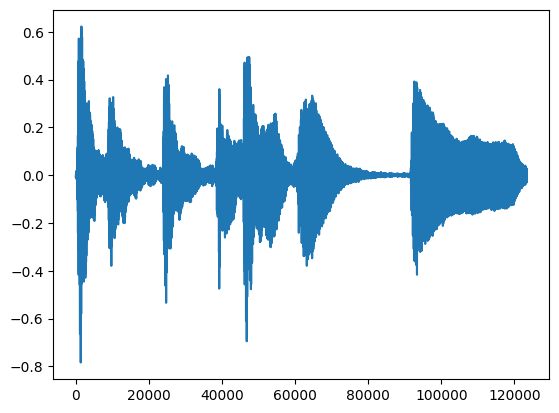

In [9]:
audio_path = 'C:/Users/bryan/Documents/GitHub/Synth/presets/MarioPiano.mp3'
audio = get_audio(audio_path)

plt.plot(audio)
plt.show()
Audio(audio, rate=SAMPLE_RATE)

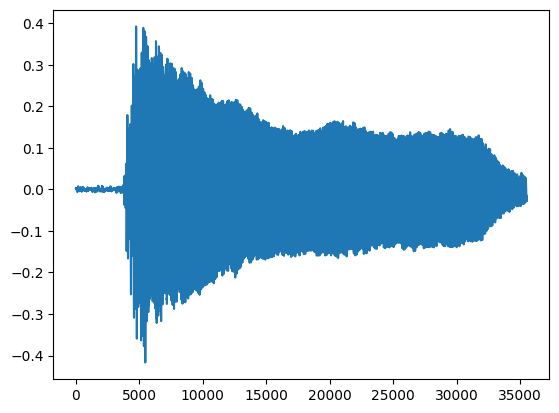

Pieces 7


In [10]:
audio_segments = split_audio(audio, prominence=0.05)

for audio_segment in [audio_segments[-1]]:
    plt.plot(audio_segment)
    plt.show()
    display(Audio(audio_segment, rate=SAMPLE_RATE))

print('Pieces', len(audio_segments))

In [11]:
estimated_presets = []
i = 1
last_best = None

if __name__ == '__main__':
    for audio_segment in [audio_segments[-1]]:
        print('Piece', i)
        target_C = evaluate_target(np.expand_dims(audio_segment, axis=0))
        duration = len(audio_segment) / SAMPLE_RATE
        if last_best is None:
            best = search_with_DE(target_C, duration, disp=False, maxiter=120)
            best = search_with_CMA(target_C, duration, best, tolfun=1e-4, tolx=1e-4, tolfunhist=1e-4, repeat_times=5)
        else:
            best = search_with_CMA(target_C, duration, last_best, tolfun=1e-4, tolx=1e-4, tolfunhist=1e-4)

        last_best = best
        estimated_presets.append((best, duration))
        i+=1

Piece 1


c:\Users\bryan\Documents\GitHub\Synth\venv\Lib\site-packages\scipy\optimize\_differentialevolution.py:487: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=654782, Sun Feb  8 14:13:49 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=670750, Sun Feb  8 14:17:02 2026)
NOTE (module=cma, iteration=3583):  
condition in coordinate system exceeded 1.0e+08, rescaled to 1.0e+00, 
condition changed from 1.1e+09 to 7.3e+04
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=712831, Sun Feb  8 14:25:35 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=600193, Sun Feb  8 14:29:05 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=675955, Sun Feb  8 14:31:54 2026)


In [12]:
predicted_joined_audio = []

for preset, duration in estimated_presets:
    preset = np.expand_dims(preset, axis=0)
    error = evaluate_presets((denormalize_preset(from_matrix_to_preset(preset)), target_C, duration))
    print('Error', error)
    # target_audio = np.expand_dims(audio_segments[0], axis=0)
    predicted_audio = render_presets(denormalize_preset(from_matrix_to_preset(preset)), duration)
    predicted_joined_audio.append(predicted_audio[0])

    denormalized_predicted_preset = denormalize_preset(from_matrix_to_preset(preset))
    pretty_print(denormalized_predicted_preset)

predicted_joined_audio = np.concatenate(predicted_joined_audio, axis=0)

Error [0.05077649]
{
  osc1_shape:   [
    1.910671377212436
  ]
  osc1_phase:   [
    0.556472005822088
  ]
  osc1_volume:   [
    0.8375048718462832
  ]
  osc1_freq:   [
    394.61686679203217
  ]
  osc2_shape:   [
    0.8901932960032641
  ]
  osc2_phase:   [
    0.15781136131459164
  ]
  osc2_volume:   [
    0.43684073641469534
  ]
  osc2_freq:   [
    3620.063189142885
  ]
  osc3_shape:   [
    1.310186869851116
  ]
  osc3_phase:   [
    0.7663963367230141
  ]
  osc3_volume:   [
    0.6354981935519921
  ]
  osc3_freq:   [
    46.23434890960585
  ]
  osc4_shape:   [
    0.5482408030530819
  ]
  osc4_phase:   [
    0.8183498334685341
  ]
  osc4_volume:   [
    0.5347627020535426
  ]
  osc4_freq:   [
    21691.06555489929
  ]
  oscnoise_volume:   [
    0.36194070159642566
  ]
  filter_envelope_attack:   [
    0.10161993663246884
  ]
  filter_envelope_decay:   [
    0.46833366164271945
  ]
  filter_envelope_sustain:   [
    0.8696352221927223
  ]
  filter_envelope_release:   [
    0.00

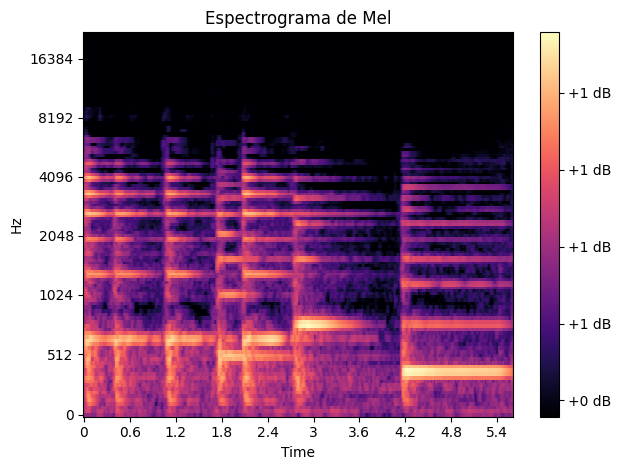

In [13]:
spect = evaluate_target(np.array([audio]))[0]
librosa.display.specshow(spect, sr=SAMPLE_RATE, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Espectrograma de Mel')
plt.tight_layout()
plt.show()

display(Audio(audio, rate=SAMPLE_RATE))

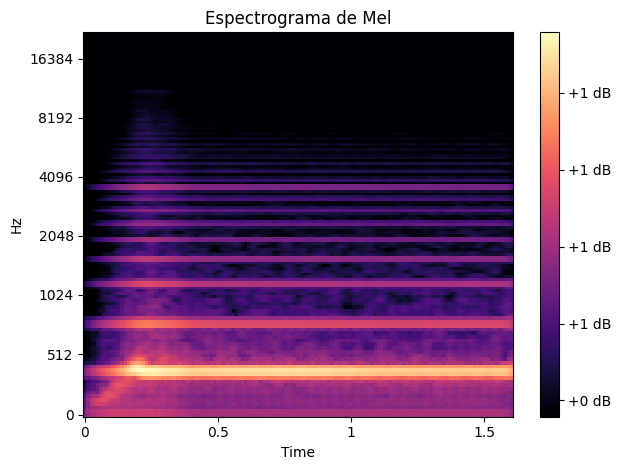

In [14]:
spect = evaluate_target(np.array([predicted_joined_audio]))[0]
librosa.display.specshow(spect, sr=SAMPLE_RATE, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Espectrograma de Mel')
plt.tight_layout()
plt.show()

display(Audio(predicted_joined_audio, rate=SAMPLE_RATE))